In [ ]:
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

In [ ]:
 #Link Google Drive with Colab to Access Data

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# define training and test data directories

data_dir = 'path/to/dataset'
train_dir = os.path.join(data_dir, 'train/')
valid_dir = os.path.join(data_dir, 'val/')
#test_dir = os.path.join(data_dir, 'test/')

# classes are folders in each directory with these names
classes = ['aedes', 'anopheles', 'cimex', 'ctenocephalides', 'culex', 'pediculus', 'triatoma' ]

In [ ]:
model_name = "densenet201"

# Number of classes in the dataset
num_classes = 7

# Batch size for training (change depending on how much memory you have)
batch_size = 16

# Number of epochs to train for
num_epochs = 30

# Flag for feature extracting. When False, we finetune the whole model,
#   when True we only update the reshaped layer params
feature_extract = False

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=30, is_inception=False):
    since = time.time()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                with torch.set_grad_enabled(phase == 'train'):
                    if is_inception and phase == 'train':
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4*loss2
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # Save history once per epoch
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.cpu().item())
            else:  # phase == 'val'
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.cpu().item())

                # update LR scheduler
                lr_scheduler.step(epoch_acc)

            # deep copy best weights
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0

    if model_name == "densenet201":
        from torchvision.models import densenet201, DenseNet201_Weights

        weights = DenseNet201_Weights.DEFAULT if use_pretrained else None
        model_ft = densenet201(weights=weights)

        # Freeze backbone if needed
        set_parameter_requires_grad(model_ft, feature_extract)

        # Replace classifier
        in_features = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(in_features, num_classes)

        input_size = 224

    return model_ft, input_size


In [ ]:
# Initialize the model for this run
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

# Print the model we just instantiated
print(model_ft)

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 188MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
print("Model name is:", model_name)


Model name is: densenet201


In [ ]:
#class weights for imbalance
class_counts = torch.tensor([2250, 2250, 1187, 2250, 2250, 532, 2250], dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.ColorJitter(0.3, 0.3, 0.3, 0.2),

        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    ]),


    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    ]),
}


In [ ]:
# Create training and validation datasets
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}


from torch.utils.data import WeightedRandomSampler

targets = [label for _, label in image_datasets['train']]
sample_weights = [class_weights[label].item() for label in targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = torch.utils.data.DataLoader(
    image_datasets['train'],
    batch_size=batch_size,
    sampler=sampler,
    num_workers=4
)

val_loader = torch.utils.data.DataLoader(
    image_datasets['val'],
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"),
    data_transforms["val"]
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

dataloaders_dict = {
    "train": train_loader,
    "val": val_loader
}

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# Send the model to GPU
model_ft = model_ft.to(device)

# Gather the parameters to be optimized/updated in this run. If we are
#  finetuning we will be updating all parameters. However, if we are
#  doing feature extract method, we will only update the parameters
#  that we have just initialized, i.e. the parameters with requires_grad
#  is True.
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

# Observe that all parameters are being optimized
optimizer_ft = optim.AdamW(params_to_update, lr=3e-5, weight_decay=1e-4)


lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='max',
    factor=0.3,
    patience=3
)

Params to learn:
	 features.conv0.weight
	 features.norm0.weight
	 features.norm0.bias
	 features.denseblock1.denselayer1.norm1.weight
	 features.denseblock1.denselayer1.norm1.bias
	 features.denseblock1.denselayer1.conv1.weight
	 features.denseblock1.denselayer1.norm2.weight
	 features.denseblock1.denselayer1.norm2.bias
	 features.denseblock1.denselayer1.conv2.weight
	 features.denseblock1.denselayer2.norm1.weight
	 features.denseblock1.denselayer2.norm1.bias
	 features.denseblock1.denselayer2.conv1.weight
	 features.denseblock1.denselayer2.norm2.weight
	 features.denseblock1.denselayer2.norm2.bias
	 features.denseblock1.denselayer2.conv2.weight
	 features.denseblock1.denselayer3.norm1.weight
	 features.denseblock1.denselayer3.norm1.bias
	 features.denseblock1.denselayer3.conv1.weight
	 features.denseblock1.denselayer3.norm2.weight
	 features.denseblock1.denselayer3.norm2.bias
	 features.denseblock1.denselayer3.conv2.weight
	 features.denseblock1.denselayer4.norm1.weight
	 features.de

In [ ]:
# Setup the loss fxn
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Train and evaluate
# Train and evaluate

model_ft, train_loss, val_loss, train_acc, val_acc = train_model(
    model_ft,
    dataloaders_dict,
    criterion,
    optimizer_ft,
    num_epochs=num_epochs,
    is_inception=False
)


Epoch 0/29
----------
train Loss: 0.4488 Acc: 0.8221
val Loss: 0.2217 Acc: 0.9264

Epoch 1/29
----------
train Loss: 0.1609 Acc: 0.9309
val Loss: 0.1530 Acc: 0.9470

Epoch 2/29
----------
train Loss: 0.1226 Acc: 0.9449
val Loss: 0.1214 Acc: 0.9588

Epoch 3/29
----------
train Loss: 0.0875 Acc: 0.9615
val Loss: 0.1073 Acc: 0.9609

Epoch 4/29
----------
train Loss: 0.0785 Acc: 0.9652
val Loss: 0.0951 Acc: 0.9686

Epoch 5/29
----------
train Loss: 0.0714 Acc: 0.9665
val Loss: 0.0928 Acc: 0.9681

Epoch 6/29
----------
train Loss: 0.0586 Acc: 0.9725
val Loss: 0.0823 Acc: 0.9712

Epoch 7/29
----------
train Loss: 0.0547 Acc: 0.9739
val Loss: 0.0864 Acc: 0.9712

Epoch 8/29
----------
train Loss: 0.0415 Acc: 0.9797
val Loss: 0.0975 Acc: 0.9696

Epoch 9/29
----------
train Loss: 0.0475 Acc: 0.9804
val Loss: 0.0932 Acc: 0.9717

Epoch 10/29
----------
train Loss: 0.0478 Acc: 0.9776
val Loss: 0.0734 Acc: 0.9748

Epoch 11/29
----------
train Loss: 0.0324 Acc: 0.9844
val Loss: 0.0777 Acc: 0.9743

Ep

In [ ]:
print("train_loss =", train_loss)
print("val_loss =", val_loss)
print("train_acc =", train_acc)
print("val_acc =", val_acc)

train_loss = [0.44876100395840657, 0.16086064618211574, 0.12261317724190114, 0.0874761443803569, 0.07848505495736313, 0.07138565955444894, 0.058618696416932986, 0.0547097509909438, 0.041486870275365545, 0.047484771356629124, 0.04780949746361923, 0.03237179854302654, 0.03389206182936637, 0.02899819636659455, 0.03934910768458007, 0.02499167964775404, 0.025693260059660106, 0.027964123523854658, 0.023138025034417357, 0.022496850518232123, 0.018383269224259743, 0.011328287734779667, 0.01246940444488709, 0.011189948365764518, 0.008651608166438219, 0.007641721946307587, 0.007622973274196473, 0.008137815187496386, 0.006736232745104147, 0.0062644740340670035]
val_loss = [0.2217449033747971, 0.15302530075850235, 0.12137817913027582, 0.10731424421914129, 0.09511873411945879, 0.09281246264162546, 0.08233342096211924, 0.08639277387802449, 0.09748606817831236, 0.09321951580773506, 0.07335274827179339, 0.07766122107420297, 0.07998078286631431, 0.08528863857538621, 0.0797946744578594, 0.07458195130691

In [ ]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    # Convert tensors to floats if needed
    train_loss = [t.cpu().item() if torch.is_tensor(t) else t for t in train_loss]
    val_loss   = [t.cpu().item() if torch.is_tensor(t) else t for t in val_loss]
    train_acc  = [t.cpu().item() if torch.is_tensor(t) else t for t in train_acc]
    val_acc    = [t.cpu().item() if torch.is_tensor(t) else t for t in val_acc]

    epochs = range(len(train_loss))

    plt.figure(figsize=(14,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

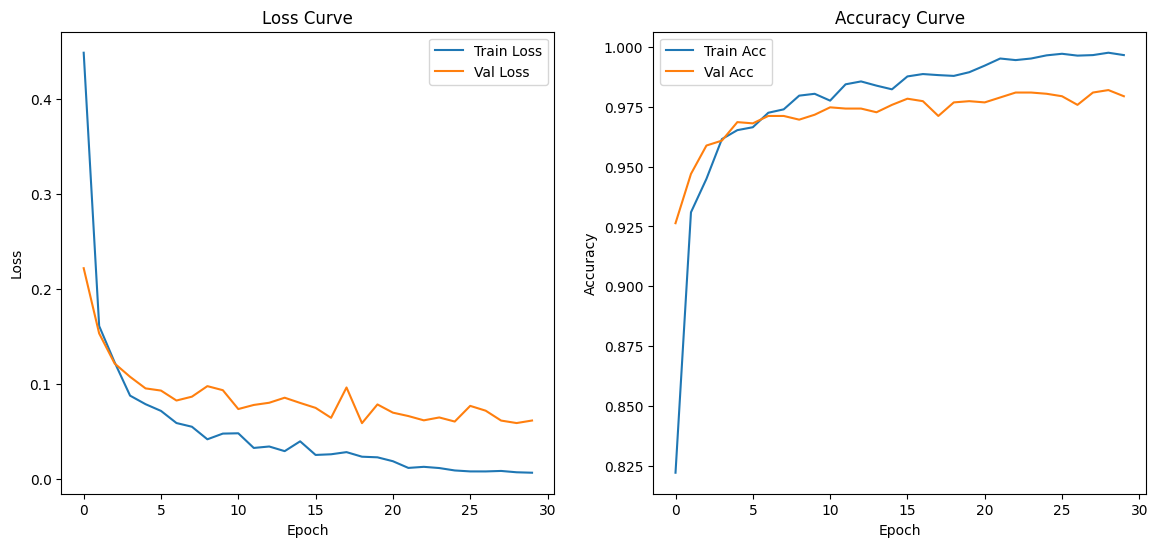

In [ ]:
plot_training_curves(train_loss, val_loss, train_acc, val_acc)

In [ ]:
test_dir = os.path.join(data_dir, "test")

test_dataset = datasets.ImageFolder(
    test_dir,
    data_transforms['val']     # Use validation transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_on_test(model, test_loader):
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    preds_list = np.array(preds_list)
    labels_list = np.array(labels_list)
    return preds_list, labels_list

In [ ]:
y_pred, y_true = evaluate_on_test(model_ft, test_loader)

In [ ]:
test_accuracy = np.mean(y_pred == y_true)
print("Test Accuracy: {:.4f}".format(test_accuracy))

Test Accuracy: 0.9779


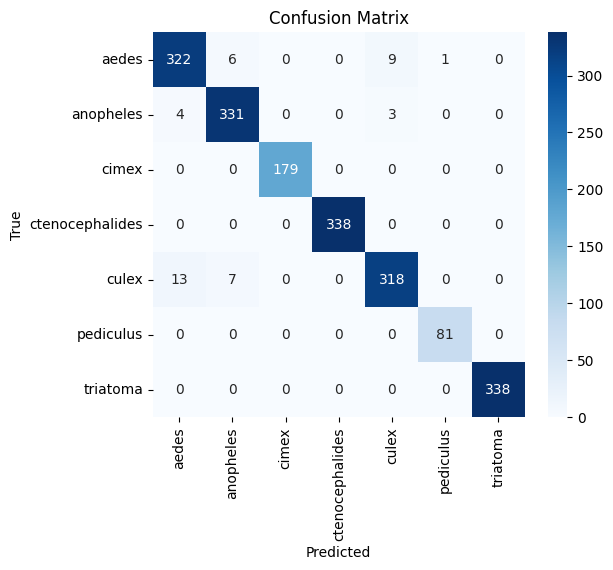

                 precision    recall  f1-score   support

          aedes       0.95      0.95      0.95       338
      anopheles       0.96      0.98      0.97       338
          cimex       1.00      1.00      1.00       179
ctenocephalides       1.00      1.00      1.00       338
          culex       0.96      0.94      0.95       338
      pediculus       0.99      1.00      0.99        81
       triatoma       1.00      1.00      1.00       338

       accuracy                           0.98      1950
      macro avg       0.98      0.98      0.98      1950
   weighted avg       0.98      0.98      0.98      1950



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Per-Class Precision, Recall, F1
print(classification_report(y_true, y_pred, target_names=classes))

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve

model_ft.eval()
all_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        all_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())

all_probs = np.vstack(all_probs)  # [N, 7]
y_true_bin = label_binarize(y_true, classes=list(range(7)))

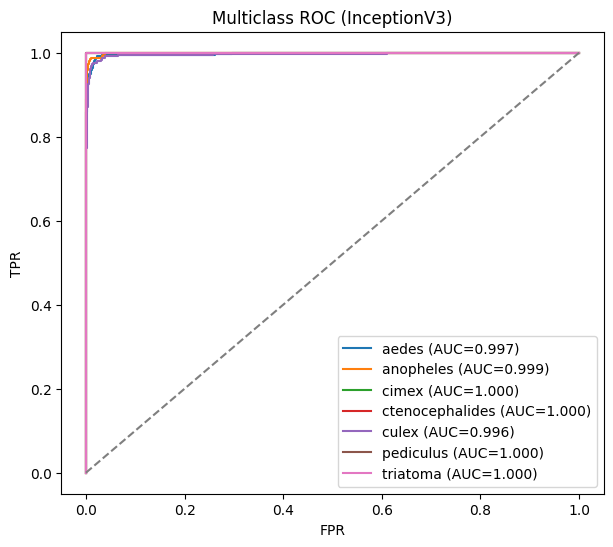

In [ ]:
plt.figure(figsize=(7,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC (DenseNet201)")
plt.legend()
plt.show()

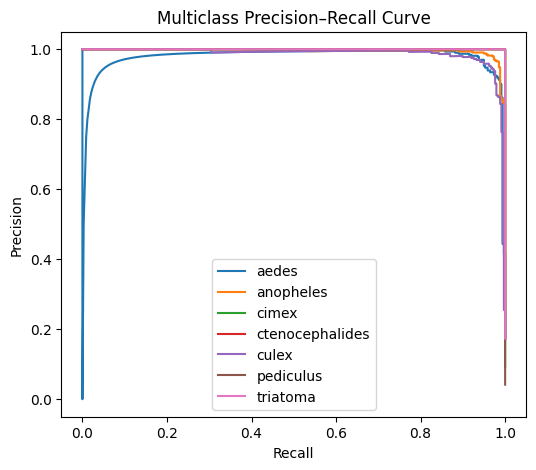

In [ ]:
plt.figure(figsize=(6,5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=cls)

plt.title("Multiclass Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [ ]:
torch.save(
    model_ft.state_dict(),
    "/content/drive/MyDrive/Insects/Models/best_denseNet.pth"
)

In [ ]:
model_ft.load_state_dict(
    torch.load("/content/drive/MyDrive/Insects/Models/best_denseNet.pth",
               map_location=device)
)
model_ft.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu